In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

36648
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

init. cond.:   0.10   0.00   0.00 




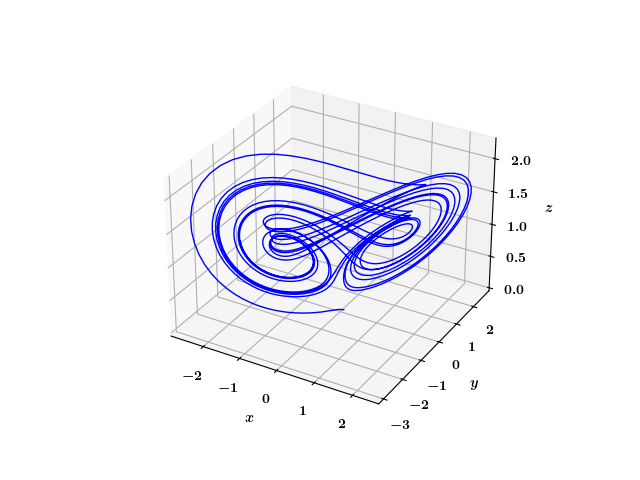

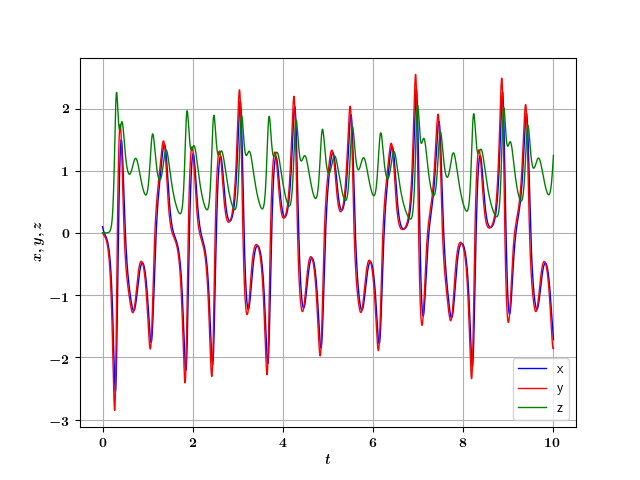

In [3]:
# ---------------------------------------------------------------
# --- Prepare the system: Chen attractor ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None
    if sel_case == 0:
        tmax, nt = 10, 11

        ss, rr, bb = 40., 28., 6.
        xi_x, xi_y, xi_z = 0., 0., 0.
        x_init = np.array([0.1, 0.0, 0.0])

        sys_coefs = {}
        sys_coefs["ss"]   = ss
        sys_coefs["rr"]   = rr
        sys_coefs["bb"]   = bb
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y
        sys_coefs["xi_z"] = xi_z

        # -------------------------------------------------------------
        def return_sys(ss_coefs):
            ss   = ss_coefs["ss"]    
            rr   = ss_coefs["rr"]    
            bb   = ss_coefs["bb"]    
            xi_x = ss_coefs["xi_x"]  
            xi_y = ss_coefs["xi_y"]  
            xi_z = ss_coefs["xi_z"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            # *** matrix F0 ***
            F_terms[0][0,0] = ss * (xi_y - xi_x)
            F_terms[0][1,0] = (rr - ss) * xi_x + rr * xi_y - (2.*rr - ss) * xi_x * xi_z
            F_terms[0][2,0] = -bb * xi_z + bb * xi_x * xi_y

            # *** matrix F1 ***
            F_terms[1][0,0], F_terms[1][0,1] = -ss, ss
            F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = (rr - ss) - (2.*rr - ss) * xi_z, rr, - (2.*rr - ss) * xi_x
            F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] = bb * xi_y, bb * xi_x, -bb 

            # *** matrix F2 ***
            F_terms[2][1,2] = - (2.*rr - ss)
            F_terms[2][2,1] = bb

            return F_terms
        
        # -------------------------------------------------------------
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new

        # --- construct the system ---
        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,0] * x[0] + F_terms[1][0,1] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1,0] * x[0] + F_terms[1][1,1] * x[1] + F_terms[1][1,2] * x[2] + F_terms[2][1,2] * x[0] * x[2],
            lambda x: F_terms[0][2,0] + F_terms[1][2,0] * x[0] + F_terms[1][2,1] * x[1] + F_terms[1][2,2] * x[2] + F_terms[2][2,1] * x[0] * x[1]
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, F_terms, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 2
F_, tmax_, nt_, Nx_, x_init_ref_, F_terms_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [10]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# --- Standard embedding ---
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

# # --- Piecewise embedding ---
# zeta_th = 0.1
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = zeta_th
# )
# radii_emb_ = np.full(len(t_emb_), zeta_th)
# case_sim_ = "Chen"
# step_t_ = 40
# del zeta_th

# --- Piecewise adaptive embedding ---
# err_tol, zeta_max, zeta_init, step_xi = 1.e-6, 0.6, 0.6, 0.02
# err_tol, zeta_max, zeta_init, step_xi = 1.e-8, 0.6, 0.6, 0.02
err_tol, zeta_max, zeta_init, step_xi = 1.e-8, 1.0, 1.0, 0.3
sol_emb_, t_emb_, case_emb_, radii_emb_ = ca.solve_carleman_global_adaptive(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_init_ = zeta_init, 
    err_tolerance_ = err_tol,
    zeta_min_    = 1e-3,
    zeta_step_   = step_xi,
    zeta_thresh_ = step_xi + 0.2,
    zeta_max_ = zeta_max
)
case_sim_ = "Chen_max{:0.2f}_tol{:0.3e}_dx{:0.2f}".format(zeta_max, err_tol, step_xi)
step_t_ = 4
del err_tol, zeta_max, zeta_init


--- t, zeta: 1.721e-01, 1.000e+00 ---
Take a smaller chart: new zeta = 7.000e-01

--- t, zeta: 2.025e-01, 7.000e-01 ---

--- t, zeta: 2.231e-01, 7.000e-01 ---

--- t, zeta: 2.386e-01, 7.000e-01 ---

--- t, zeta: 2.536e-01, 7.000e-01 ---
Take a smaller chart: new zeta = 4.000e-01

--- t, zeta: 2.596e-01, 4.000e-01 ---

--- t, zeta: 2.656e-01, 4.000e-01 ---

--- t, zeta: 2.757e-01, 4.000e-01 ---
Take a smaller chart: new zeta = 2.000e-01

--- t, zeta: 2.768e-01, 2.000e-01 ---
Take a larger chart: new zeta = 4.000e-01

--- t, zeta: 2.828e-01, 4.000e-01 ---
Take a larger chart: new zeta = 8.000e-01

--- t, zeta: 2.937e-01, 8.000e-01 ---
>>> The non-shifted chart is unstable
Take a smaller chart: new zeta = 5.000e-01

--- t, zeta: 2.977e-01, 5.000e-01 ---
>>> The non-shifted chart is unstable

--- t, zeta: 3.086e-01, 5.000e-01 ---
>>> The non-shifted chart is unstable

--- t, zeta: 3.195e-01, 5.000e-01 ---
Take a larger chart: new zeta = 1.000e+00

--- t, zeta: 3.303e-01, 1.000e+00 ---

--

In [30]:
step_t_ = 20

write data to a file: ./jupyter-notebooks/Carleman/results//REF_Chen_max1.00_tol1.000e-08_dx0.30_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_Chen_max1.00_tol1.000e-08_dx0.30_PAE_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_Chen_max1.00_tol1.000e-08_dx0.30_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_Chen_max1.00_tol1.000e-08_dx0.30_PAE_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_Chen_max1.00_tol1.000e-08_dx0.30_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_Chen_max1.00_tol1.000e-08_dx0.30_PAE_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_Chen_max1.00_tol1.000e-08_dx0.30_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_Chen_max1.00_tol1.000e-08_dx0.30_PAE_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_Chen_max1.00_tol1.000e-08_dx0.30_PAE_err_x.dat
write data to a file: ./jupyter-notebooks/Car

c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:1072: RuntimeWarning: invalid value encountered in divide
  err = abs(s_ref[ivar] - s_emb_int[ivar]) / abs(s_ref[ivar])
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:1121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


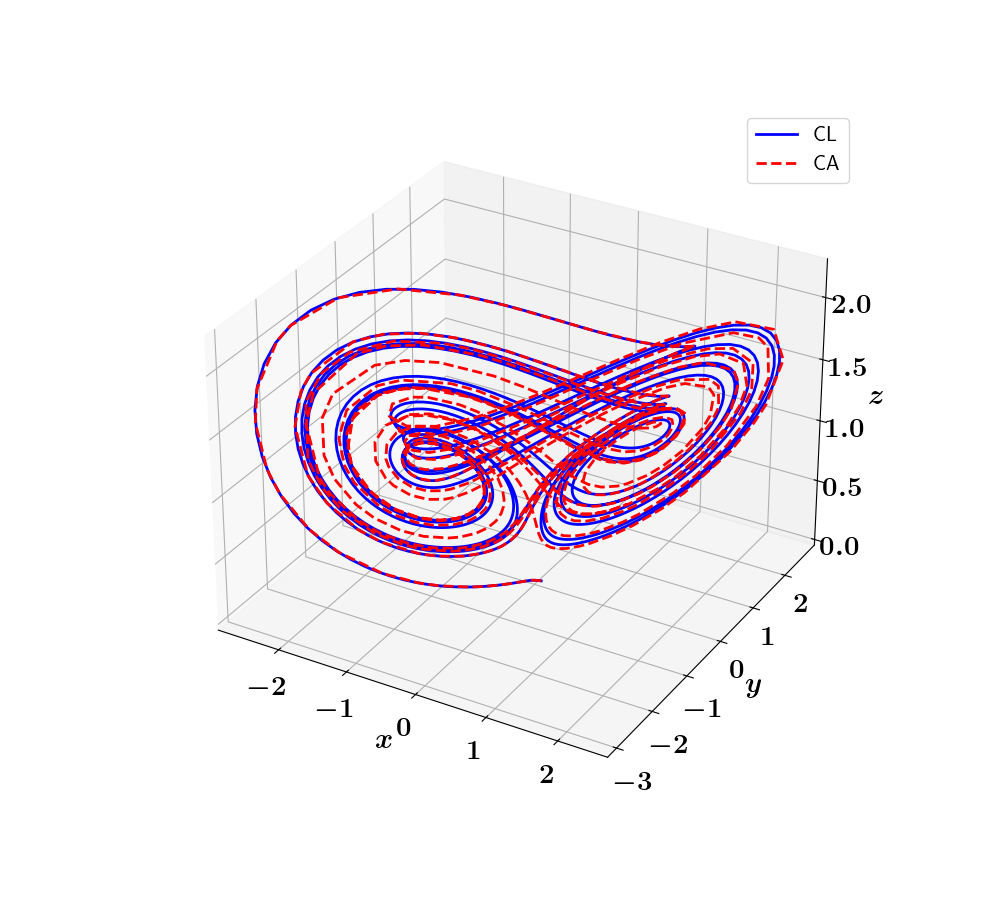

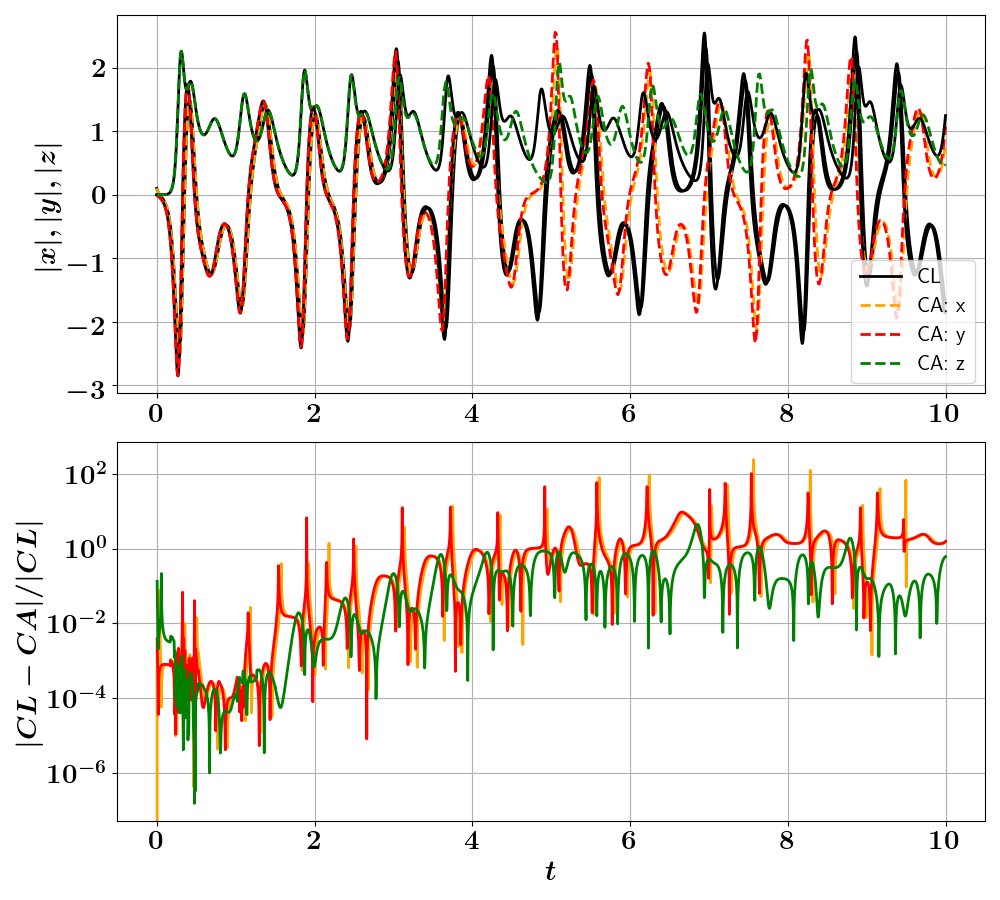

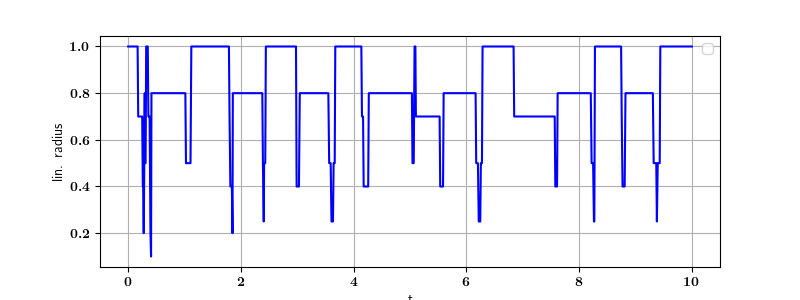

In [12]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=True, path_save=path_save_, 
    case_title = case_sim_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    radii_emb = radii_emb_,
    flag_var_semilogy = False,
    step_t = step_t_
)

In [2]:
ii = 0
while ii < 10:
    print(ii)
    if ii == 8:
        break
    ii += 1
    print("here\n")
print("Done")

0
here

1
here

2
here

3
here

4
here

5
here

6
here

7
here

8
Done
